# Notebook 02 — EDA & Preprocessing du dataset SWRO

**PFE — Master Science des Données**

## Objectif

Explorer le dataset synthétique produit par le modèle physique SWRO V3 et préparer les données pour les modèles de Machine Learning.

Pipeline :

**Chargement → Qualité des données → EDA → Corrélations → Outliers → Sélection X/y → Train/Test → Standardisation → Sauvegarde**

> La variable cible est `SEC_kWh_m3`, la consommation énergétique spécifique.

In [1]:
# ============================================================
# 0. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

DATA_FILE = Path("data/dataset_physical_v3.csv")
OUTPUT_DIR = Path("data/preprocessed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration chargée.")
print("Dataset :", DATA_FILE)

Configuration chargée.
Dataset : data\dataset_physical_v3.csv


## 1. Chargement du dataset V3

In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset introuvable : {DATA_FILE}\n"
        "Place dataset_physical_v3.csv dans le dossier data/"
    )

df = pd.read_csv(DATA_FILE)

print("Shape :", df.shape)
display(df.head())

Shape : (10000, 25)


,pressure_bar,feed_flow_m3_h,salinity_g_L,temperature_C,recovery_rate_target,effective_recovery_rate,pump_efficiency,erd_efficiency,membrane_condition,osmotic_pressure_feed_bar,...,flux_permeate_L_m2_h,membrane_area_m2,permeate_flow_m3_h,concentrate_flow_m3_h,hydraulic_power_kW,pump_power_kW,recovered_power_kW,net_power_kW,SEC_physical_kWh_m3,SEC_kWh_m3
0,60.618102,498.912655,39.839986,24.572169,0.344837,0.344837,0.877085,0.918649,0.760665,29.879990,...,21.275939,8086.291607,172.043446,326.869208,840.087169,957.816749,404.495186,553.321563,3.216173,3.184662
1,69.260715,466.329677,35.476096,21.889387,0.314223,0.314223,0.824178,0.940976,0.957126,26.607072,...,33.353656,4393.262114,146.531354,319.798323,897.175741,1088.570944,463.158161,625.412783,4.268116,4.305624
2,65.979909,340.923130,36.773118,29.467478,0.318954,0.318954,0.779320,0.874109,0.812327,27.579838,...,33.843298,3213.007111,108.738756,232.184374,624.835476,801.770265,297.575841,504.194424,4.636750,4.605504
3,63.979877,685.813336,39.306245,18.284677,0.327101,0.327101,0.860496,0.846269,0.820984,29.479684,...,21.727996,10324.467854,224.330001,461.483335,1218.840363,1416.438872,555.258399,861.180472,3.838900,3.889449
4,57.340280,581.299328,37.856715,23.817846,0.330548,0.330548,0.812802,0.851015,0.806561,28.392536,...,20.260279,9483.942996,192.147330,389.151998,925.885167,1139.127962,421.991791,717.136171,3.732220,3.690048


## 2. Structure et types

In [3]:
print("Types de données :")
display(df.dtypes)

print("\nInformations générales :")
df.info()

Types de données :


pressure_bar                        float64
feed_flow_m3_h                      float64
salinity_g_L                        float64
temperature_C                       float64
recovery_rate_target                float64
effective_recovery_rate             float64
pump_efficiency                     float64
erd_efficiency                      float64
membrane_condition                  float64
osmotic_pressure_feed_bar           float64
osmotic_pressure_concentrate_bar    float64
osmotic_pressure_avg_bar            float64
net_membrane_pressure_bar           float64
temperature_factor                  float64
membrane_factor                     float64
flux_permeate_L_m2_h                float64
membrane_area_m2                    float64
permeate_flow_m3_h                  float64
concentrate_flow_m3_h               float64
hydraulic_power_kW                  float64
pump_power_kW                       float64
recovered_power_kW                  float64
net_power_kW                    


Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   pressure_bar                      10000 non-null  float64
 1   feed_flow_m3_h                    10000 non-null  float64
 2   salinity_g_L                      10000 non-null  float64
 3   temperature_C                     10000 non-null  float64
 4   recovery_rate_target              10000 non-null  float64
 5   effective_recovery_rate           10000 non-null  float64
 6   pump_efficiency                   10000 non-null  float64
 7   erd_efficiency                    10000 non-null  float64
 8   membrane_condition                10000 non-null  float64
 9   osmotic_pressure_feed_bar         10000 non-null  float64
 10  osmotic_pressure_concentrate_bar  10000 non-null  float64
 11  osmotic_pressure_avg_bar          10000 no

## 3. Qualité des données

On vérifie les valeurs manquantes, doublons et valeurs infinies.

In [4]:
missing = df.isna().sum()
duplicates = df.duplicated().sum()
infinite_values = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

print("Valeurs manquantes :", missing.sum())
print("Doublons :", duplicates)
print("Valeurs infinies :", infinite_values)

if missing.sum() > 0:
    display(missing[missing > 0])

assert missing.sum() == 0, "Des valeurs manquantes sont présentes."
assert duplicates == 0, "Des doublons sont présents."
assert infinite_values == 0, "Des valeurs infinies sont présentes."

print("Contrôle qualité : OK")

Valeurs manquantes : 0
Doublons : 0
Valeurs infinies : 0
Contrôle qualité : OK


## 4. Statistiques descriptives

In [5]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
pressure_bar,10000.0,62.412393,4.314452,55.000175,58.694933,62.387929,66.100095,69.995765
feed_flow_m3_h,10000.0,603.623901,231.435641,200.126196,403.156641,604.717421,805.183377,999.939861
salinity_g_L,10000.0,38.000403,2.294190,34.000385,36.029983,38.016545,39.957391,41.999208
temperature_C,10000.0,22.480701,4.334919,15.000083,18.702859,22.500454,26.206744,29.996841
recovery_rate_target,10000.0,0.374530,0.043393,0.300003,0.336641,0.374058,0.412572,0.449996
effective_recovery_rate,10000.0,0.374530,0.043393,0.300003,0.336641,0.374058,0.412572,0.449996
pump_efficiency,10000.0,0.825472,0.043251,0.750001,0.788543,0.825914,0.863017,0.899991
erd_efficiency,10000.0,0.880286,0.046025,0.800043,0.840622,0.880674,0.920395,0.959950
membrane_condition,10000.0,0.874806,0.071492,0.750033,0.813000,0.874808,0.936956,0.999969
osmotic_pressure_feed_bar,10000.0,28.500302,1.720643,25.500289,27.022487,28.512409,29.968043,31.499406


## 5. Distribution de la variable cible

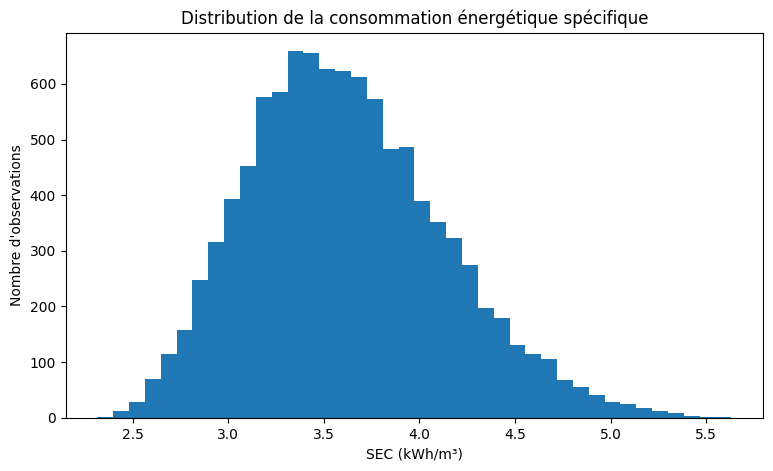

Moyenne : 3.617898348608412
Médiane : 3.573790555831339
Min : 2.315995052845768
Max : 5.63130544584337


In [6]:
target = "SEC_kWh_m3"

plt.figure(figsize=(9, 5))
plt.hist(df[target], bins=40)
plt.xlabel("SEC (kWh/m³)")
plt.ylabel("Nombre d'observations")
plt.title("Distribution de la consommation énergétique spécifique")
plt.show()

print("Moyenne :", df[target].mean())
print("Médiane :", df[target].median())
print("Min :", df[target].min())
print("Max :", df[target].max())

## 6. Histogrammes des variables numériques

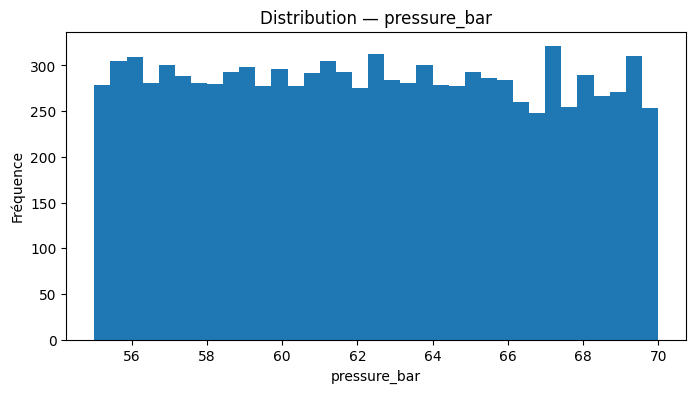

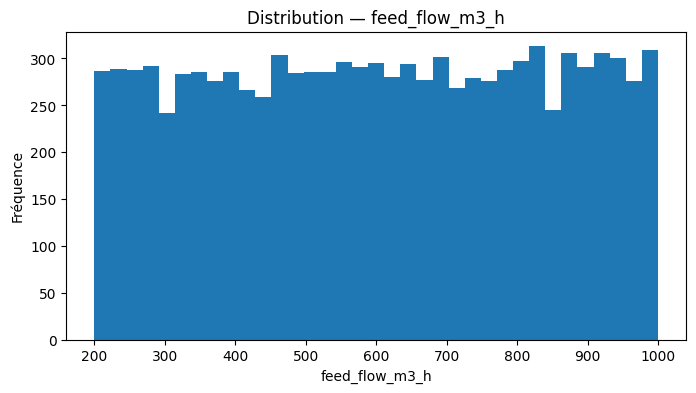

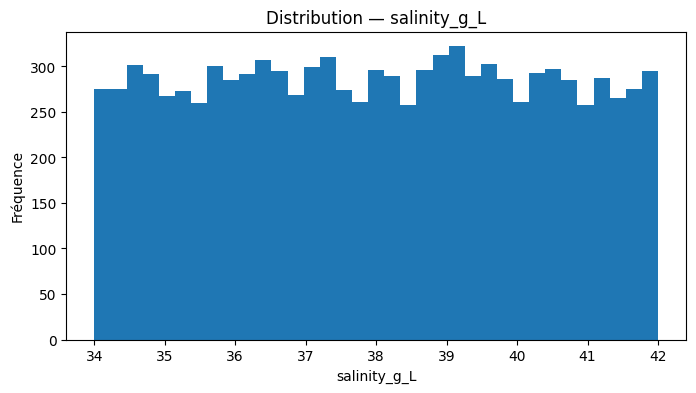

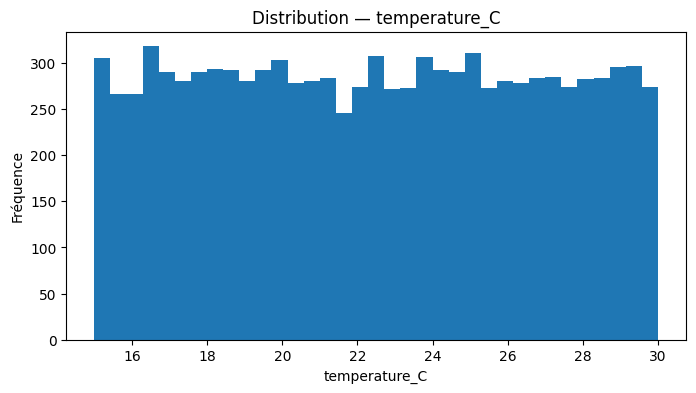

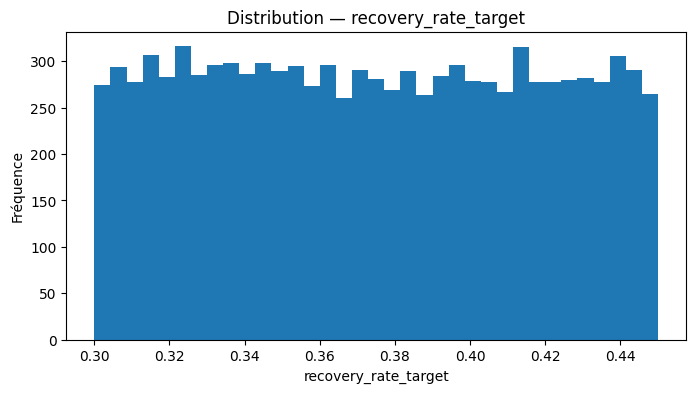

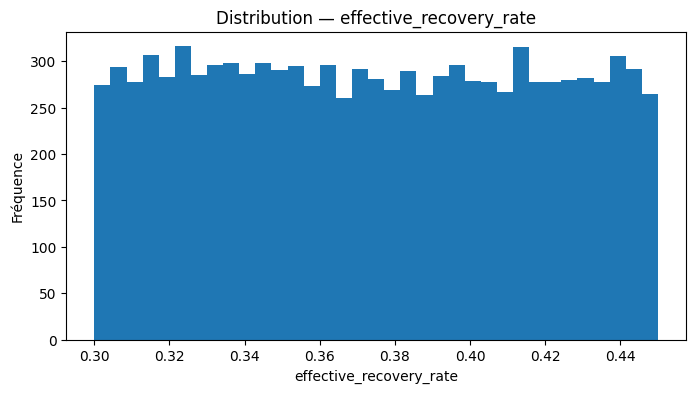

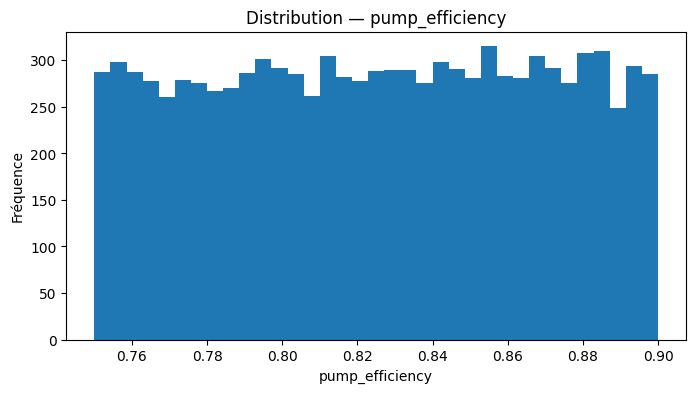

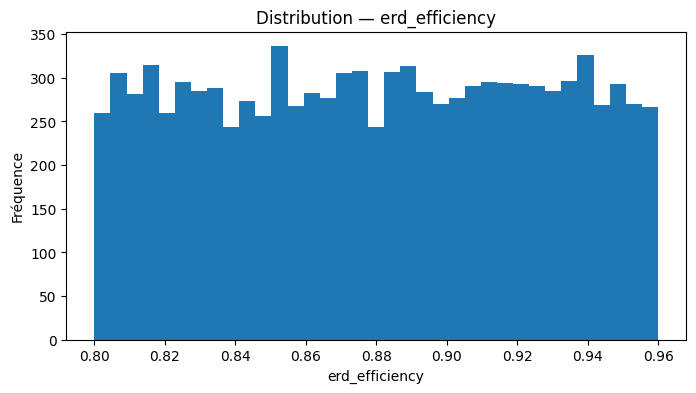

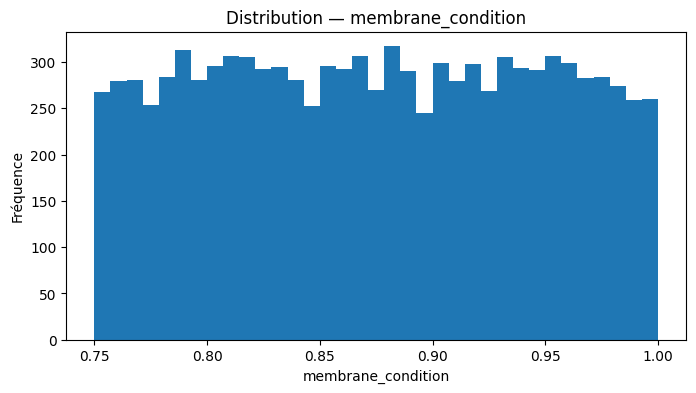

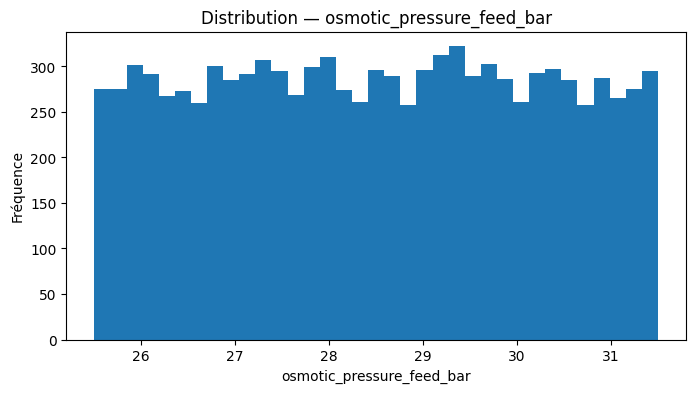

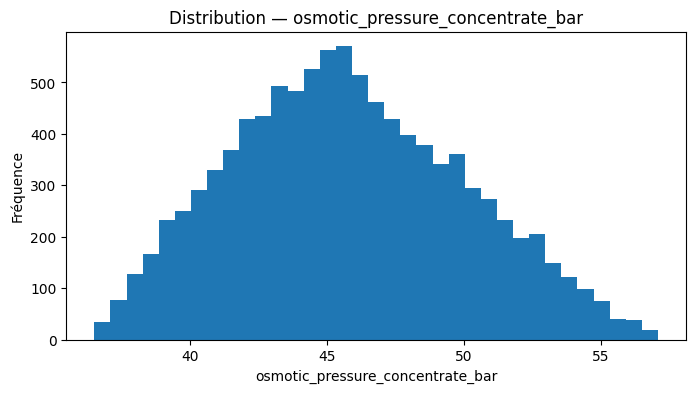

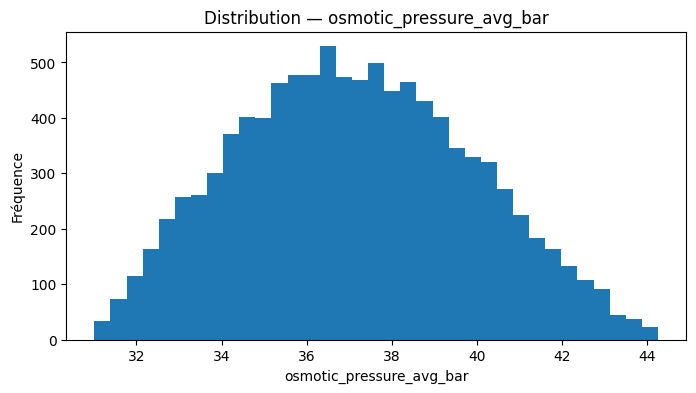

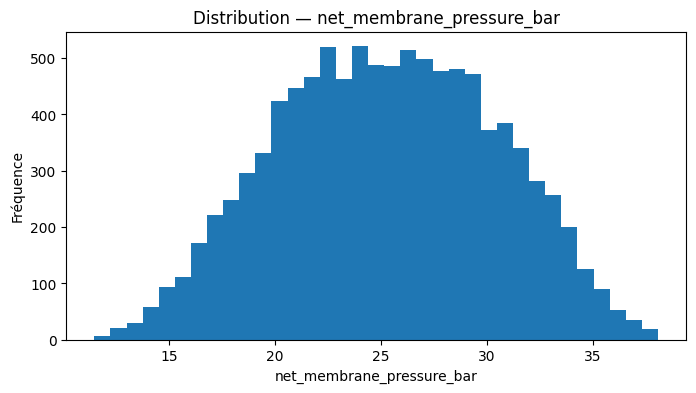

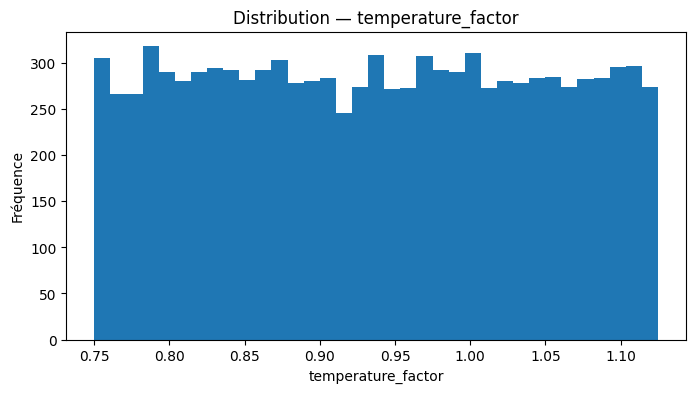

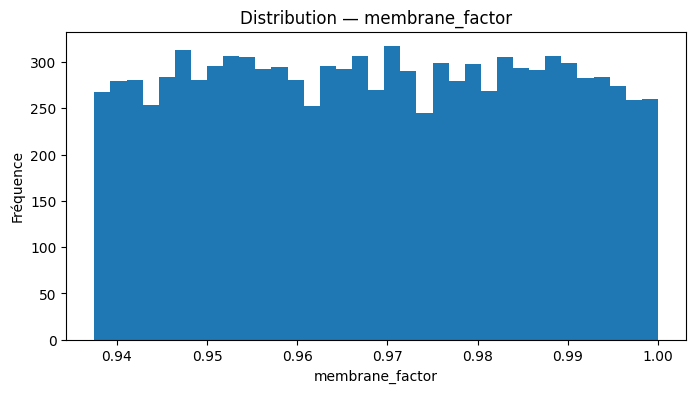

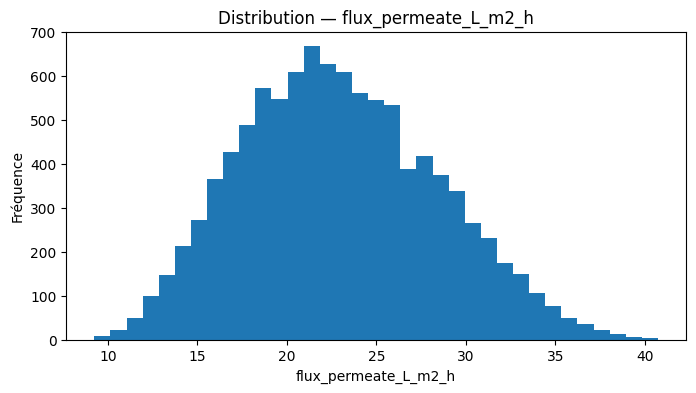

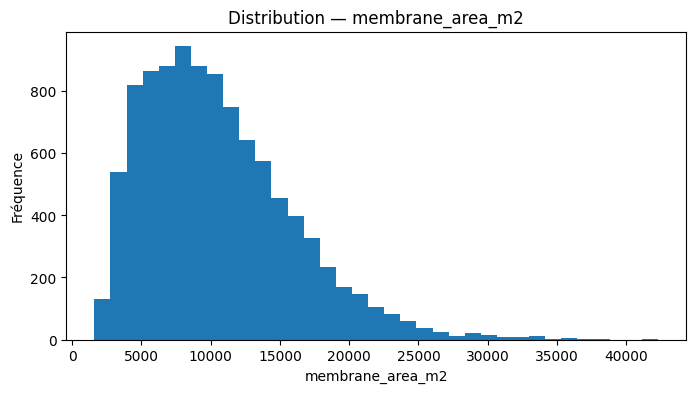

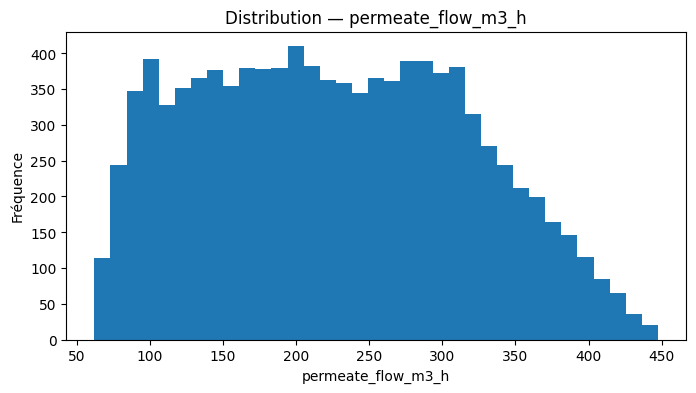

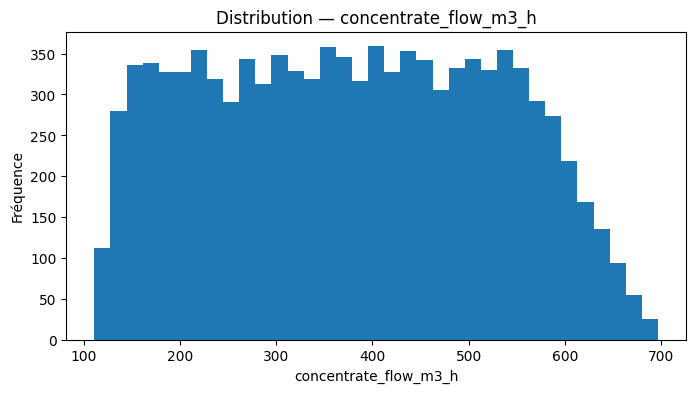

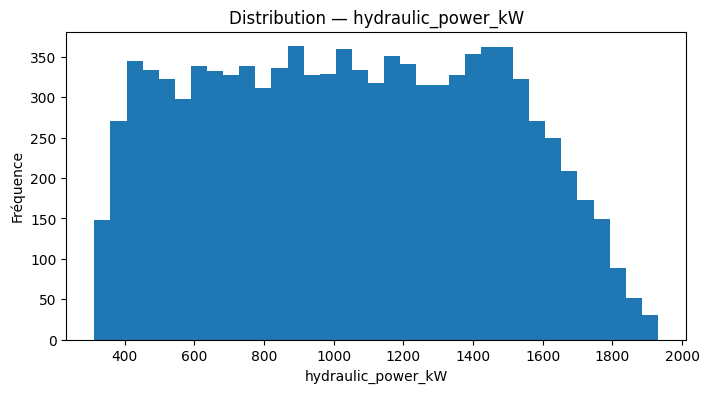

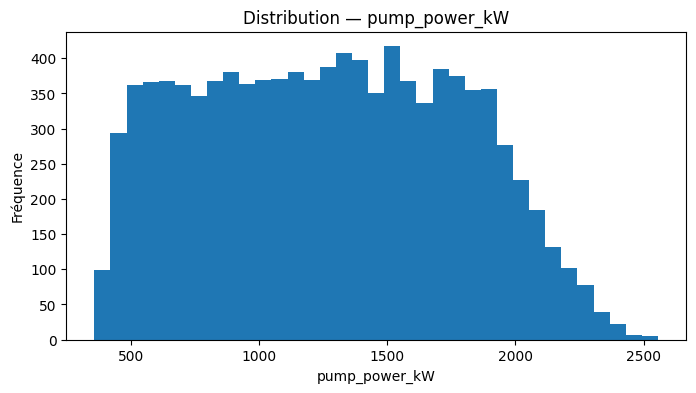

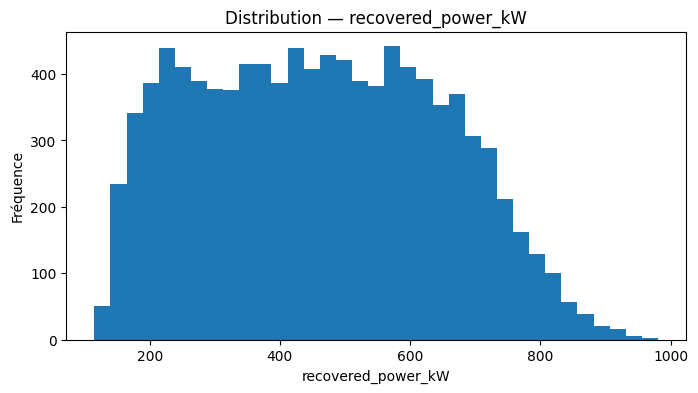

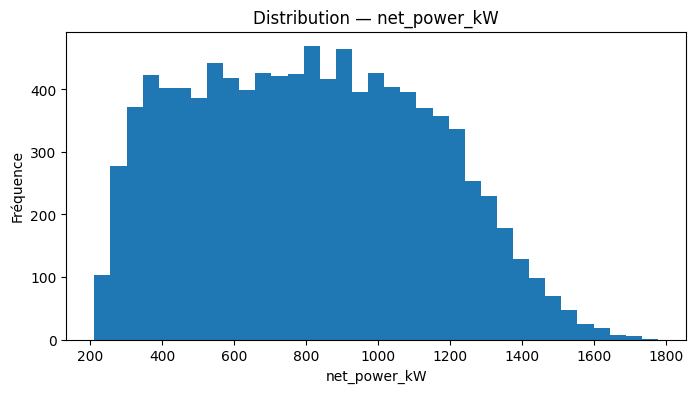

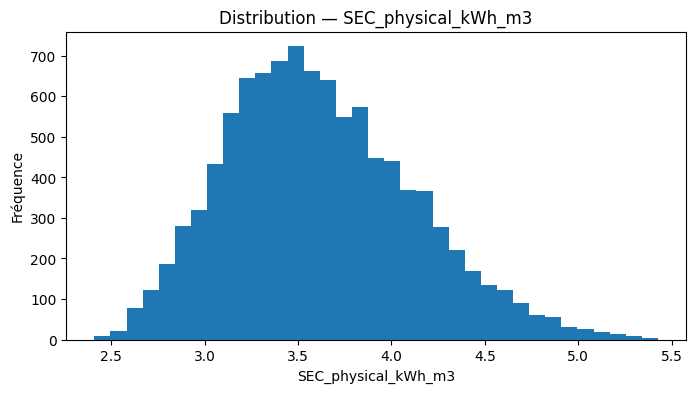

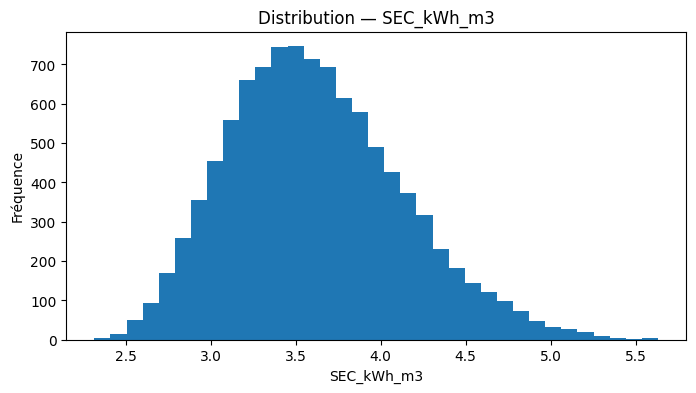

In [7]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=35)
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.title(f"Distribution — {col}")
    plt.show()

## 7. Analyse des corrélations

In [8]:
corr = df.corr(numeric_only=True)

target_corr = (
    corr[target]
    .sort_values(ascending=False)
)

print("Corrélations avec SEC :")
display(target_corr.to_frame("correlation"))

Corrélations avec SEC :


,correlation
SEC_kWh_m3,1.000000
SEC_physical_kWh_m3,0.977173
net_membrane_pressure_bar,0.592236
flux_permeate_L_m2_h,0.509472
pressure_bar,0.504604
net_power_kW,0.172400
pump_power_kW,0.170149
recovered_power_kW,0.156597
concentrate_flow_m3_h,0.099928
hydraulic_power_kW,0.091613


## 8. Scatter plots des variables principales

Ces graphiques permettent d'observer visuellement les relations entre les variables physiques et la SEC.

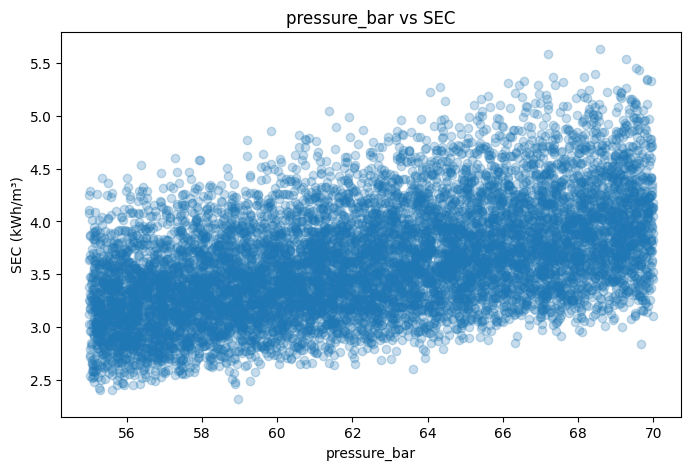

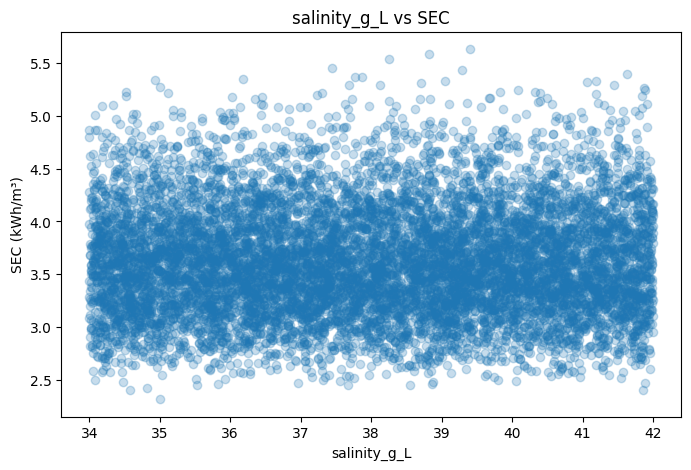

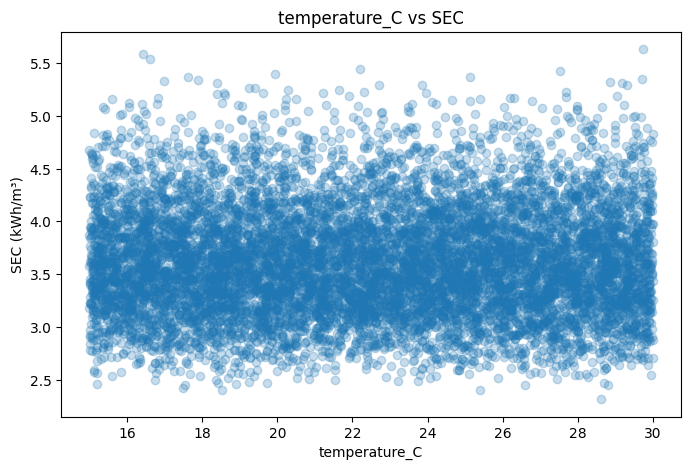

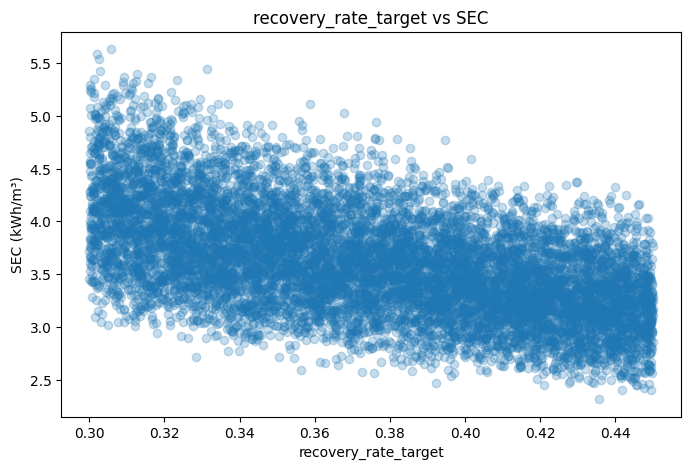

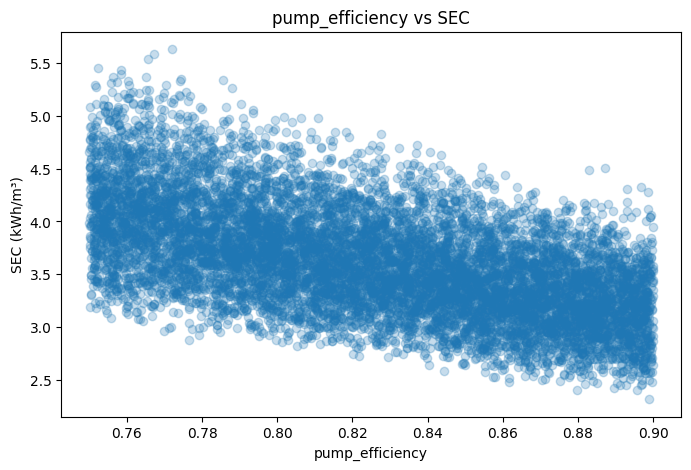

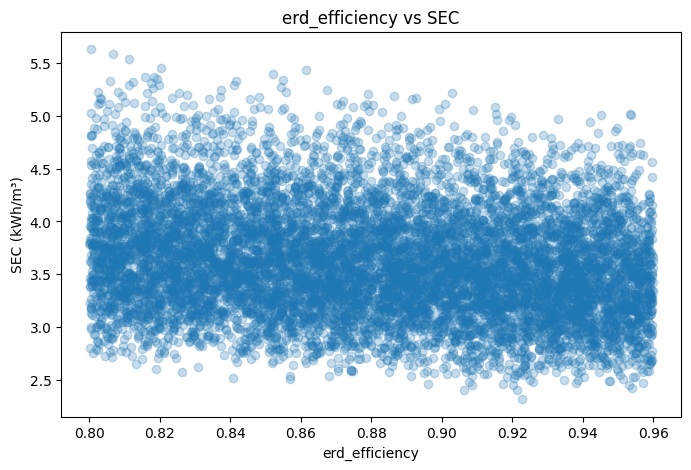

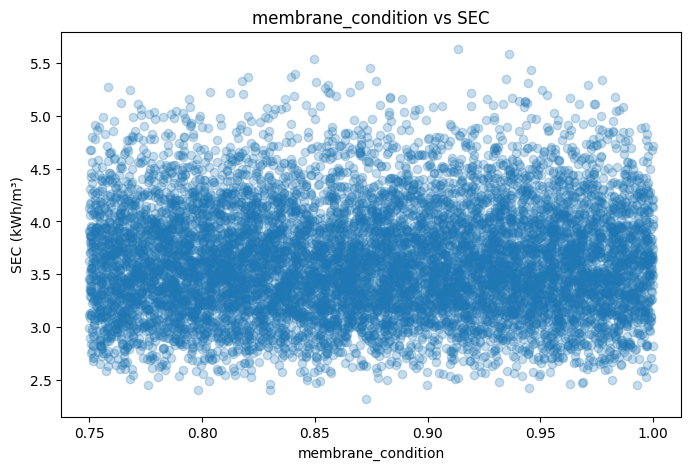

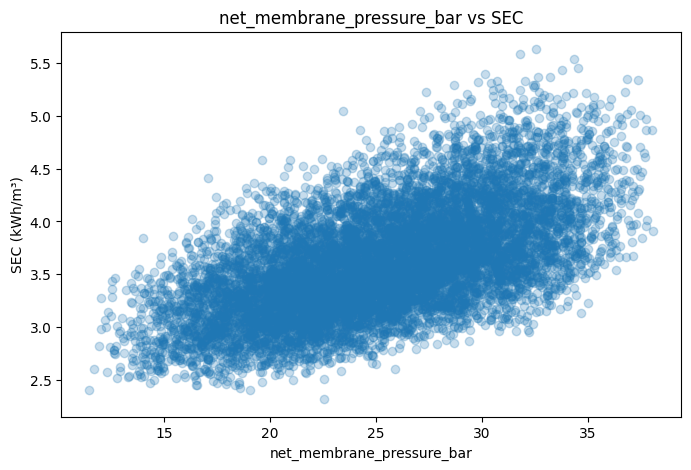

In [9]:
main_features = [
    "pressure_bar",
    "salinity_g_L",
    "temperature_C",
    "recovery_rate_target",
    "pump_efficiency",
    "erd_efficiency",
    "membrane_condition",
    "net_membrane_pressure_bar",
]

for col in main_features:
    plt.figure(figsize=(8, 5))
    plt.scatter(df[col], df[target], alpha=0.25)
    plt.xlabel(col)
    plt.ylabel("SEC (kWh/m³)")
    plt.title(f"{col} vs SEC")
    plt.show()

## 9. Détection des outliers — méthode IQR

Les outliers sont identifiés mais **pas supprimés automatiquement**. Dans un procédé industriel, une valeur extrême peut correspondre à un fonctionnement réel.

In [10]:
outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count,
        "outlier_percent": 100 * count / len(df)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.sort_values("outlier_count", ascending=False))

,variable,Q1,Q3,lower_bound,upper_bound,outlier_count,outlier_percent
16,membrane_area_m2,6471.435528,13652.988436,-4300.893834,24425.317798,159,1.59
24,SEC_kWh_m3,3.246682,3.939887,2.206875,4.979694,91,0.91
23,SEC_physical_kWh_m3,3.252770,3.943464,2.216730,4.979504,77,0.77
15,flux_permeate_L_m2_h,18.904717,26.668892,7.258453,38.315156,17,0.17
4,recovery_rate_target,0.336641,0.412572,0.222745,0.526468,0,0.00
1,feed_flow_m3_h,403.156641,805.183377,-199.883463,1408.223481,0,0.00
2,salinity_g_L,36.029983,39.957391,30.138872,45.848502,0,0.00
3,temperature_C,18.702859,26.206744,7.447031,37.462571,0,0.00
0,pressure_bar,58.694933,66.100095,47.587190,77.207839,0,0.00
8,membrane_condition,0.813000,0.936956,0.627066,1.122889,0,0.00


## 10. Choix des variables pour le Machine Learning

On exclut les variables qui constituent directement des résultats intermédiaires du calcul énergétique lorsque cela pourrait créer une fuite d'information (*data leakage*).

Pour le premier modèle ML, nous utilisons principalement les **conditions de fonctionnement disponibles en entrée**.

In [11]:
features = [
    "pressure_bar",
    "feed_flow_m3_h",
    "salinity_g_L",
    "temperature_C",
    "recovery_rate_target",
    "pump_efficiency",
    "erd_efficiency",
    "membrane_condition",
]

X = df[features].copy()
y = df[target].copy()

print("Features :")
for feature in features:
    print(" -", feature)

print("\nX :", X.shape)
print("y :", y.shape)

Features :
 - pressure_bar
 - feed_flow_m3_h
 - salinity_g_L
 - temperature_C
 - recovery_rate_target
 - pump_efficiency
 - erd_efficiency
 - membrane_condition

X : (10000, 8)
y : (10000,)


## 11. Train / Validation / Test split

Nous utilisons :

- **70 % train**
- **15 % validation**
- **15 % test**

Le test reste complètement indépendant jusqu'à l'évaluation finale.

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (7000, 8)
Validation : (1500, 8)
Test : (1500, 8)


## 12. Standardisation

La standardisation est ajustée **uniquement sur le train** afin d'éviter une fuite d'information.

\[
z = \frac{x-\mu_{train}}{\sigma_{train}}
\]

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=features,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=X_test.index
)

print("Standardisation terminée.")

Standardisation terminée.


## 13. Vérification de la standardisation

In [14]:
print("Moyennes du train après scaling :")
display(X_train_scaled.mean().round(6))

print("\nÉcarts-types du train après scaling :")
display(X_train_scaled.std().round(6))

Moyennes du train après scaling :


pressure_bar            0.0
feed_flow_m3_h         -0.0
salinity_g_L            0.0
temperature_C           0.0
recovery_rate_target    0.0
pump_efficiency        -0.0
erd_efficiency         -0.0
membrane_condition     -0.0
dtype: float64


Écarts-types du train après scaling :


pressure_bar            1.000071
feed_flow_m3_h          1.000071
salinity_g_L            1.000071
temperature_C           1.000071
recovery_rate_target    1.000071
pump_efficiency         1.000071
erd_efficiency          1.000071
membrane_condition      1.000071
dtype: float64

## 14. Vérification de la fuite de données

Les paramètres du scaler doivent provenir uniquement du train.

In [15]:
print("Mean appris par le scaler :")
display(pd.Series(scaler.mean_, index=features))

print("\nScale appris par le scaler :")
display(pd.Series(scaler.scale_, index=features))

Mean appris par le scaler :


pressure_bar             62.387287
feed_flow_m3_h          604.084910
salinity_g_L             37.992859
temperature_C            22.469751
recovery_rate_target      0.374399
pump_efficiency           0.825411
erd_efficiency            0.880347
membrane_condition        0.874675
dtype: float64


Scale appris par le scaler :


pressure_bar              4.320893
feed_flow_m3_h          231.983250
salinity_g_L              2.299622
temperature_C             4.340926
recovery_rate_target      0.043264
pump_efficiency           0.043270
erd_efficiency            0.046065
membrane_condition        0.071474
dtype: float64

## 15. Sauvegarde des données préparées

Les fichiers suivants seront utilisés dans les notebooks ML suivants :

- `X_train_scaled.csv`
- `X_val_scaled.csv`
- `X_test_scaled.csv`
- `y_train.csv`
- `y_val.csv`
- `y_test.csv`
- `scaler_parameters.csv`
- `feature_names.csv`

In [16]:
X_train_scaled.to_csv(OUTPUT_DIR / "X_train_scaled.csv", index=False)
X_val_scaled.to_csv(OUTPUT_DIR / "X_val_scaled.csv", index=False)
X_test_scaled.to_csv(OUTPUT_DIR / "X_test_scaled.csv", index=False)

y_train.to_csv(OUTPUT_DIR / "y_train.csv", index=False, header=True)
y_val.to_csv(OUTPUT_DIR / "y_val.csv", index=False, header=True)
y_test.to_csv(OUTPUT_DIR / "y_test.csv", index=False, header=True)

pd.DataFrame({
    "feature": features,
    "mean_train": scaler.mean_,
    "std_train": scaler.scale_
}).to_csv(
    OUTPUT_DIR / "scaler_parameters.csv",
    index=False
)

pd.DataFrame({"feature": features}).to_csv(
    OUTPUT_DIR / "feature_names.csv",
    index=False
)

print("Fichiers sauvegardés dans :", OUTPUT_DIR.resolve())

Fichiers sauvegardés dans : C:\Users\UltraPc\Documents\pfe\code\data\preprocessed


# Conclusion

Le dataset est maintenant prêt pour le Machine Learning.

### Pipeline obtenu

```text
dataset_physical_v3.csv
        ↓
       EDA
        ↓
Qualité / distributions
        ↓
Corrélations
        ↓
Détection des outliers
        ↓
Sélection des features
        ↓
Train / Validation / Test
        ↓
StandardScaler
        ↓
Données prêtes pour ML
```

### Notebook suivant

**Notebook 03 — ML Baseline**

Nous comparerons plusieurs modèles de régression :

1. Linear Regression
2. Ridge
3. Random Forest
4. Gradient Boosting
5. MLP Regressor

Les performances seront évaluées avec **MAE, RMSE et R²**, puis nous comparerons les modèles.